In [1]:
# import necessary libraries
import os
import umap
import random
import numpy as np
import pandas as pd
import seaborn as sns
from torch import optim
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

from utils import*
from cgmvae import*
from loss_cgmvae import*
from data_builder import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# initialize parameters 
data_path = '/home/rachel/Desktop/mm-vae_ext2/data/agg_data_subset2.csv'
output_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v3'
os.makedirs(output_path, exist_ok=True)
input_type = 'agg' # 'raw' or 'agg'

# model parameters
latent_dim = 8
gmm_centers_path = '/home/rachel/Desktop/mm-vae_ext2/data/gmm_centers_ld8_std10_v2.csv'
gmm_std = 8
num_gaussian = 2
input_dim = 16
hidden_dim = 16

# training parameters
batch_size = 128
epochs = 1000
learning_rate = 0.001
num_samples = 128 # should be less than or equal to batch size 
log_interval = 10
kl_weight = 0.1

# random
random_seed = 10

In [3]:
%%writefile ~/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v3/config.txt
# initialize parameters 
data_path = '/home/rachel/Desktop/mm-vae_ext2/data/agg_data_subset2.csv'
output_path = '/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v3'
input_type = 'agg' # 'raw' or 'agg'

# model parameters
latent_dim = 8
gmm_centers_path = '/home/rachel/Desktop/mm-vae_ext2/data/gmm_centers_ld8_std10_v2.csv'
gmm_std = 8
num_gaussian = 2
input_dim = 16
hidden_dim = 16

# training parameters
batch_size = 128
epochs = 1000
learning_rate = 0.001
num_samples = 128 # should be less than or equal to batch size 
log_interval = 10
kl_weight = 0.1

# random
random_seed = 10

Overwriting /home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data_subset2/agg_ld8_1000epochs_v3/config.txt


In [4]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set seed
np.random.seed = random_seed
random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

In [5]:
# initialize gaussian mixture distributions
df_gmm = pd.read_csv(gmm_centers_path)
gmm_centers = torch.tensor([df_gmm[col].values for col in df_gmm.columns]).float()
gmm_centers = gmm_centers.T

# # calculate weights
ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, gmm_centers, gmm_std, num_samples)

/tmp/ipykernel_3529876/2375554694.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  gmm_centers = torch.tensor([df_gmm[col].values for col in df_gmm.columns]).float()


In [5]:
# for inputting raw data to MLP
class DataBuilder_AggData(Dataset):
    def __init__(self, data):
        self.x, self.genotype, self.sex, self.AD_label = load_agg_data(data)
        self.len = self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.genotype[index], self.sex[index], self.AD_label[index]
    def __len__(self):
        return self.len

def load_agg_data(df):
    x = df.iloc[:, 8:].values.astype('float32')
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    x_standardized = (x - mean) / (std + 1e-8)
    genotype = df['Genotype (F>M)'].tolist()
    sex = df['Sex'].tolist()
    labels = df['AD_label'] = np.where(
        (df['Genotype (F>M)'].str.contains('attp2', case=False, na=False)) | (df['Genotype (F>M)'].str.contains('attp4', case=False, na=False)), 
        0, 
        1
    )
    return x_standardized, genotype, sex, labels

In [8]:
#  save mean and std of standardization
def calc_zscore(df):
    x = df.iloc[:, 8:-1]
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    mean.to_csv('/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data/agg_mean.csv', index=False)
    std.to_csv('/home/rachel/Desktop/drosophila_sleep_analysis/agg_input_data/agg_std.csv', index=False)

In [9]:
# load in data and create dataloaders 
if input_type == 'raw':
    beam_break_data = pd.read_csv(data_path)
    train_set = DataBuilder(beam_break_data)
else: 
    aggregated_data = pd.read_csv(data_path)
    train_set = DataBuilder_AggData(aggregated_data)
    calc_zscore(aggregated_data)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(train_set, batch_size=len(train_set), shuffle=True)

model = CGMVAE(num_gaussian, latent_dim, input_dim, hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
def train(epoch, model, train_loader, device, optimizer, log_interval, test_loader, latent_dim, output_folder, kl_weight, total_epochs):
    model.train()
    train_loss = 0
    recon_loss = 0
    kld_loss = 0
    #for batch_idx, (data, fly_id, genotype, AD_labels) in enumerate(train_loader):
    for batch_idx, (data, genotype, sex, AD_labels) in enumerate(train_loader):
        data = data.to(device)
        AD_labels = AD_labels.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar, z = model(data, AD_labels)
        loss, recons, kld = get_gmmvaeloss(recon_batch, z, data, ks_weight, cv_weight, kl_weight, gmm_centers, gmm_std)
        loss.backward()
        train_loss += loss.item()
        recon_loss += recons.item()
        kld_loss += kld.item()
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)))

    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss / len(train_loader.dataset)))

    train_loss /= len(train_loader.dataset)
    recon_loss /= len(train_loader.dataset)
    kld_loss /= len(train_loader.dataset)

    step = total_epochs / 5
    if epoch in [step, step * 2, step * 3, step * 4, step * 5]:
        try: 
            with torch.no_grad():
                #test_data, test_flyids, test_genotype, test_ad_labels = next(iter(test_loader))
                test_data, test_genotype, test_sex, test_ad_labels = next(iter(test_loader))
                test_data = test_data.to(device)
                test_ad_labels = test_ad_labels.to(device)
                recons, mu, logvar, z = model.forward(test_data, test_ad_labels)
                latent_vectors = z.detach().cpu().numpy()
                latent_space = pd.DataFrame(latent_vectors, columns=[f'LV{i+1}' for i in range(latent_dim)])
                #latent_space['flyID'] = list(test_flyids)
                latent_space['genotype'] = list(test_genotype)
                latent_space['Sex'] = list(test_sex)
                test_ad_labels = test_ad_labels.detach().cpu().numpy()
                latent_space['ad_label'] = list(test_ad_labels)
                latent_space.to_csv(os.path.join(output_folder, f'latent_variables_epoch{epoch}.csv'), index=False)
                print('Latent variables saved')

                mu = pd.DataFrame(mu.detach().cpu().numpy())
                mu.to_csv(os.path.join(output_folder, f'mu_epoch{epoch}.csv'), index=False)

                recons = pd.DataFrame(recons.detach().cpu().numpy())
                #recons['flyID'] = list(test_flyids)
                recons['genotype'] = list(test_genotype)
                recons['Sex'] = list(test_sex)
                recons['ad_label'] = list(test_ad_labels)
                recons.to_csv(os.path.join(output_folder, f'recons_epoch{epoch}.csv'), index=False)

                torch.save(model, os.path.join(output_folder, f'saved_model_epoch{epoch}.pth'))
                print('Model saved')

        except Exception as e: 
            print(f'Error during saving/plotting LV at epoch {epoch}: {e}')

    return train_loss, recon_loss, kld_loss

/home/rachel/Desktop/mm-vae_ext2/mm-vae/loss_cgmvae.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  if math.isnan(losses):


Train Epoch: 1 [0/1340 (0%)]	Loss: 0.193458
Train Epoch: 1 [600/1340 (91%)]	Loss: 0.411084
====> Epoch: 1 Average loss: 0.2032
Train Epoch: 2 [0/1340 (0%)]	Loss: 0.192889
Train Epoch: 2 [600/1340 (91%)]	Loss: 0.409441
====> Epoch: 2 Average loss: 0.2025
Train Epoch: 3 [0/1340 (0%)]	Loss: 0.192130
Train Epoch: 3 [600/1340 (91%)]	Loss: 0.410695
====> Epoch: 3 Average loss: 0.2020
Train Epoch: 4 [0/1340 (0%)]	Loss: 0.192719
Train Epoch: 4 [600/1340 (91%)]	Loss: 0.404636
====> Epoch: 4 Average loss: 0.2008
Train Epoch: 5 [0/1340 (0%)]	Loss: 0.190156
Train Epoch: 5 [600/1340 (91%)]	Loss: 0.405018
====> Epoch: 5 Average loss: 0.1998
Train Epoch: 6 [0/1340 (0%)]	Loss: 0.191747
Train Epoch: 6 [600/1340 (91%)]	Loss: 0.400230
====> Epoch: 6 Average loss: 0.1988
Train Epoch: 7 [0/1340 (0%)]	Loss: 0.191155
Train Epoch: 7 [600/1340 (91%)]	Loss: 0.401932
====> Epoch: 7 Average loss: 0.1975
Train Epoch: 8 [0/1340 (0%)]	Loss: 0.186145
Train Epoch: 8 [600/1340 (91%)]	Loss: 0.392228
====> Epoch: 8 Avera

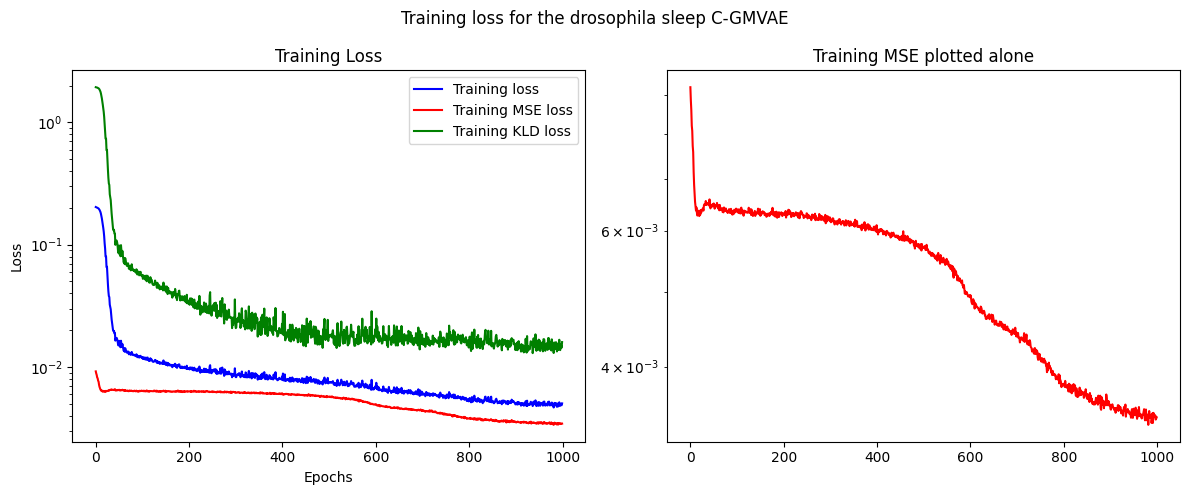

In [10]:
total_train_loss = []
total_bce_loss = []
total_kld_loss = []

for epoch in range(1, epochs + 1):
    train_loss, bce_loss, kld_loss = train(epoch, model, train_loader, device, optimizer, log_interval, test_loader, latent_dim, output_path, kl_weight, epochs)
    total_train_loss.append(train_loss)
    total_bce_loss.append(bce_loss)
    total_kld_loss.append(kld_loss)

fix, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax[0].plot(total_train_loss, color = 'blue', label='Training loss')
ax[0].plot(total_bce_loss, color='red', label='Training MSE loss')
ax[0].plot(total_kld_loss, color='green', label='Training KLD loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training Loss')
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(total_bce_loss, color='red', label='Training MSE loss')
ax[1].set_title('Training MSE plotted alone')
ax[1].set_yscale('log')

plt.suptitle('Training loss for the drosophila sleep C-GMVAE')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'train_test_loss.png'))

Visualize latent space

In [11]:
end_latent_space = pd.read_csv(os.path.join(output_path, f'latent_variables_epoch{epochs}.csv'))
end_latent_space

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,genotype,Sex,ad_label
0,1.885201,1.236801,-4.164433,3.089558,0.121012,-4.522163,-1.781363,-5.639186,SwedArc>alrm,M,1
1,-2.608624,-5.162991,-8.944674,0.121479,-4.048537,-7.637767,1.729576,-3.760275,elavQF>QA40,F,1
2,1.063165,-1.287242,-2.093038,3.817318,-1.726617,-5.352411,1.916243,-2.731626,elavQF>QA42,M,1
3,-12.377917,-9.647761,-11.444790,-11.132614,-5.334301,-19.077408,-15.442392,-13.191717,attp40>alrm,F,0
4,-15.343477,-16.166338,-10.934461,-10.925862,-7.858479,-17.224937,-16.162907,-13.409073,attp2>nsybG4,vF,0
...,...,...,...,...,...,...,...,...,...,...,...
1335,-16.168783,-14.549886,-8.887120,-7.834528,-9.061195,-17.224130,-17.511280,-15.683625,elav>attp2,vF,0
1336,-14.972527,-13.253504,-6.032849,-9.926724,-5.967706,-16.073076,-17.131712,-13.191082,attp40>60104,M,0
1337,-11.792824,-9.510890,-8.847446,-3.221055,-2.876655,-17.656132,-13.000326,-8.356151,attp40>64626,F,0
1338,0.067049,-0.510393,-8.206557,2.340186,-1.055261,-5.846177,-1.555768,-5.211159,SwedArc>nsybG4,M,1


In [12]:
ad_label_mapping = {0: 'Control', 1: 'AD'}
end_latent_space['ad_label'] = end_latent_space['ad_label'].map(ad_label_mapping)
if 'Sex' not in end_latent_space: 
    end_latent_space['Sex'] = np.where(
        end_latent_space['genotype'].str.endswith('F'), 
        'Female', 
        'Male'
    )
else: 
    end_latent_space['Sex'] = np.where(
        end_latent_space['Sex'].str.endswith('F'), 
        'Female', 
        'Male'
    )
end_latent_space['Control_geno'] = np.where(
    end_latent_space['genotype'].str.contains('attp2', case=False, na=False), 
    'Control_attp2', 
    np.where(
        end_latent_space['genotype'].str.contains('attp4', case=False, na=False), 
        'Control_attp4', 
        'AD'
    )
)

In [13]:
end_latent_space

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,genotype,Sex,ad_label,Control_geno
0,1.885201,1.236801,-4.164433,3.089558,0.121012,-4.522163,-1.781363,-5.639186,SwedArc>alrm,Male,AD,AD
1,-2.608624,-5.162991,-8.944674,0.121479,-4.048537,-7.637767,1.729576,-3.760275,elavQF>QA40,Female,AD,AD
2,1.063165,-1.287242,-2.093038,3.817318,-1.726617,-5.352411,1.916243,-2.731626,elavQF>QA42,Male,AD,AD
3,-12.377917,-9.647761,-11.444790,-11.132614,-5.334301,-19.077408,-15.442392,-13.191717,attp40>alrm,Female,Control,Control_attp4
4,-15.343477,-16.166338,-10.934461,-10.925862,-7.858479,-17.224937,-16.162907,-13.409073,attp2>nsybG4,Female,Control,Control_attp2
...,...,...,...,...,...,...,...,...,...,...,...,...
1335,-16.168783,-14.549886,-8.887120,-7.834528,-9.061195,-17.224130,-17.511280,-15.683625,elav>attp2,Female,Control,Control_attp2
1336,-14.972527,-13.253504,-6.032849,-9.926724,-5.967706,-16.073076,-17.131712,-13.191082,attp40>60104,Male,Control,Control_attp4
1337,-11.792824,-9.510890,-8.847446,-3.221055,-2.876655,-17.656132,-13.000326,-8.356151,attp40>64626,Female,Control,Control_attp4
1338,0.067049,-0.510393,-8.206557,2.340186,-1.055261,-5.846177,-1.555768,-5.211159,SwedArc>nsybG4,Male,AD,AD


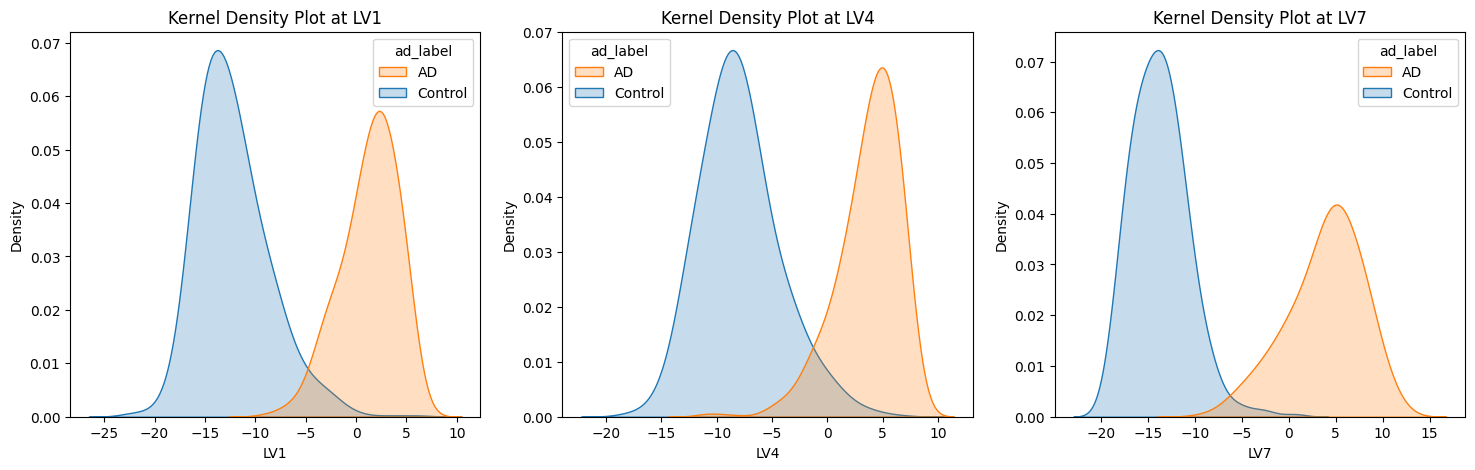

In [14]:
color_mapping_ad = {'Control': '#1f77b4', 'AD': '#ff7f0e'}
color_mapping_geno = {'Control_attp2': '#1f77b4', 'AD': '#ff7f0e', 'Control_attp4': '#2ca02c'}
color_mapping_sex = {'Female': 'purple', 'Male': 'gold'}
random_latents = random.sample(range(0, len(end_latent_space.columns[:-4])), 3)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
sns.kdeplot(data=end_latent_space, x=end_latent_space.iloc[:, random_latents[0]], fill=True, ax=axes[0], hue='ad_label', palette=color_mapping_ad, bw_adjust=1.5)
axes[0].set_title('Kernel Density Plot at LV' + str(random_latents[0]+1))
sns.kdeplot(data=end_latent_space, x=end_latent_space.iloc[:, random_latents[1]], fill=True, ax=axes[1], hue='ad_label', palette=color_mapping_ad, bw_adjust=1.5)
axes[1].set_title('Kernel Density Plot at LV' + str(random_latents[1]+1))
sns.kdeplot(data=end_latent_space,x=end_latent_space.iloc[:, random_latents[2]], fill=True, ax=axes[2], hue='ad_label', palette=color_mapping_ad, bw_adjust=1.5)
axes[2].set_title('Kernel Density Plot at LV' + str(random_latents[2]+1))
plt.savefig(os.path.join(output_path, 'example_kde_latentplots.png'))

Text(0.5, 1.0, 'Kernel Density Plot at LV4')

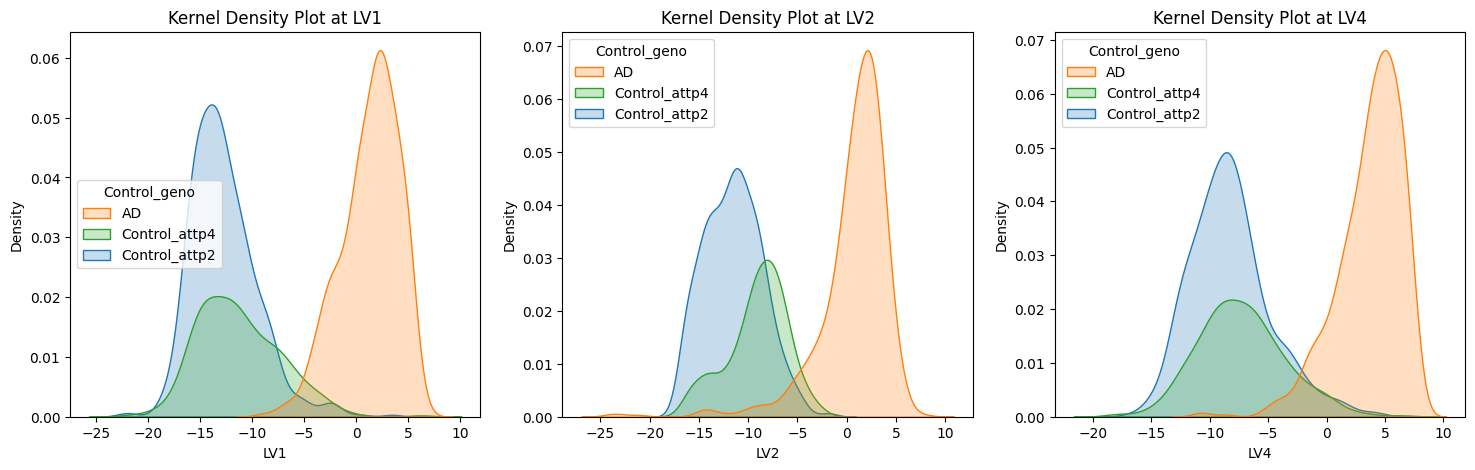

In [15]:
random_latents = random.sample(range(0, len(end_latent_space.columns[:-4])), 3)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
sns.kdeplot(data=end_latent_space, x=end_latent_space.iloc[:, random_latents[0]], fill=True, ax=axes[0], hue='Control_geno', palette=color_mapping_geno)
axes[0].set_title('Kernel Density Plot at LV' + str(random_latents[0]+1))
sns.kdeplot(data=end_latent_space, x=end_latent_space.iloc[:, random_latents[1]], fill=True, ax=axes[1], hue='Control_geno', palette=color_mapping_geno)
axes[1].set_title('Kernel Density Plot at LV' + str(random_latents[1]+1))
sns.kdeplot(data=end_latent_space,x=end_latent_space.iloc[:, random_latents[2]], fill=True, ax=axes[2], hue='Control_geno', palette=color_mapping_geno)
axes[2].set_title('Kernel Density Plot at LV' + str(random_latents[2]+1))

In [16]:
reducer = umap.UMAP(n_neighbors=10, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(end_latent_space.iloc[:, :-5])
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
embedding_df['ad_label'] = end_latent_space['ad_label']
embedding_df['Sex'] = end_latent_space['Sex']
embedding_df['Control_geno'] = end_latent_space['Control_geno']

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


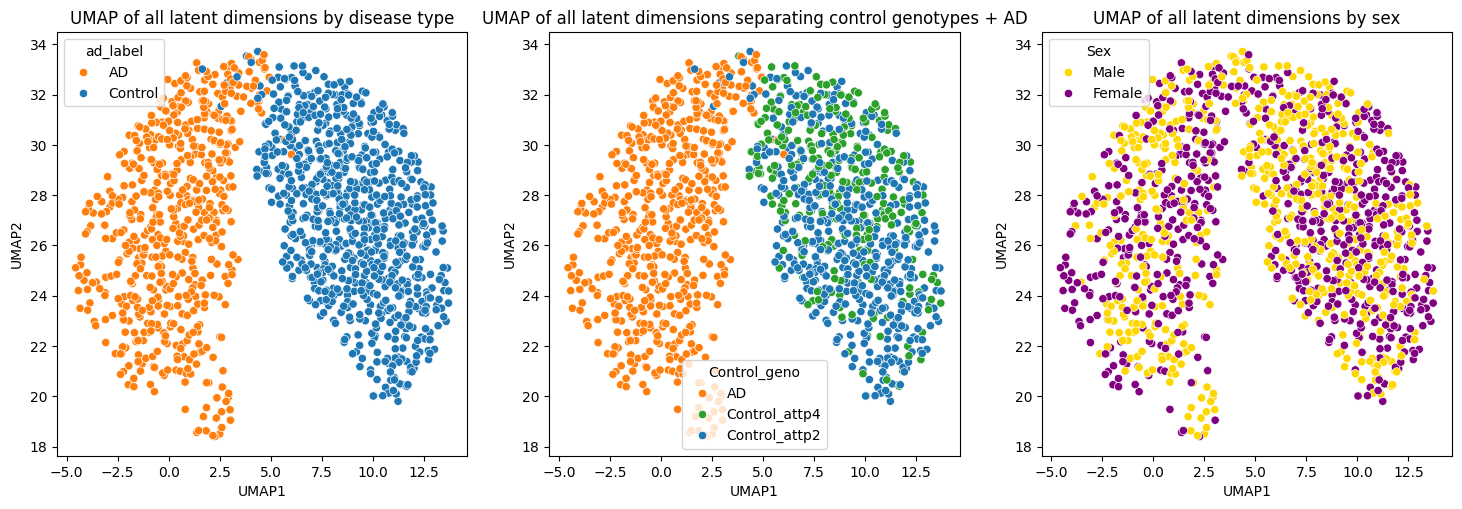

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5.5))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='ad_label', data=embedding_df, palette=color_mapping_ad, ax=axes[0])
axes[0].set_title('UMAP of all latent dimensions by disease type')
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Control_geno', data=embedding_df, palette=color_mapping_geno, ax=axes[1])
axes[1].set_title('UMAP of all latent dimensions separating control genotypes + AD')
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Sex', data=embedding_df, palette=color_mapping_sex, ax=axes[2])
axes[2].set_title('UMAP of all latent dimensions by sex')
plt.savefig(os.path.join(output_path, 'umap_latent_compression.png'))


In [18]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embedding = tsne.fit_transform(end_latent_space.iloc[:, :-5])
tsne_embedding_df = pd.DataFrame(tsne_embedding, columns=['TSNE1', 'TSNE2'])
tsne_embedding_df['ad_label'] = end_latent_space['ad_label']
tsne_embedding_df['Sex'] = end_latent_space['Sex']
tsne_embedding_df['Control_geno'] = end_latent_space['Control_geno']

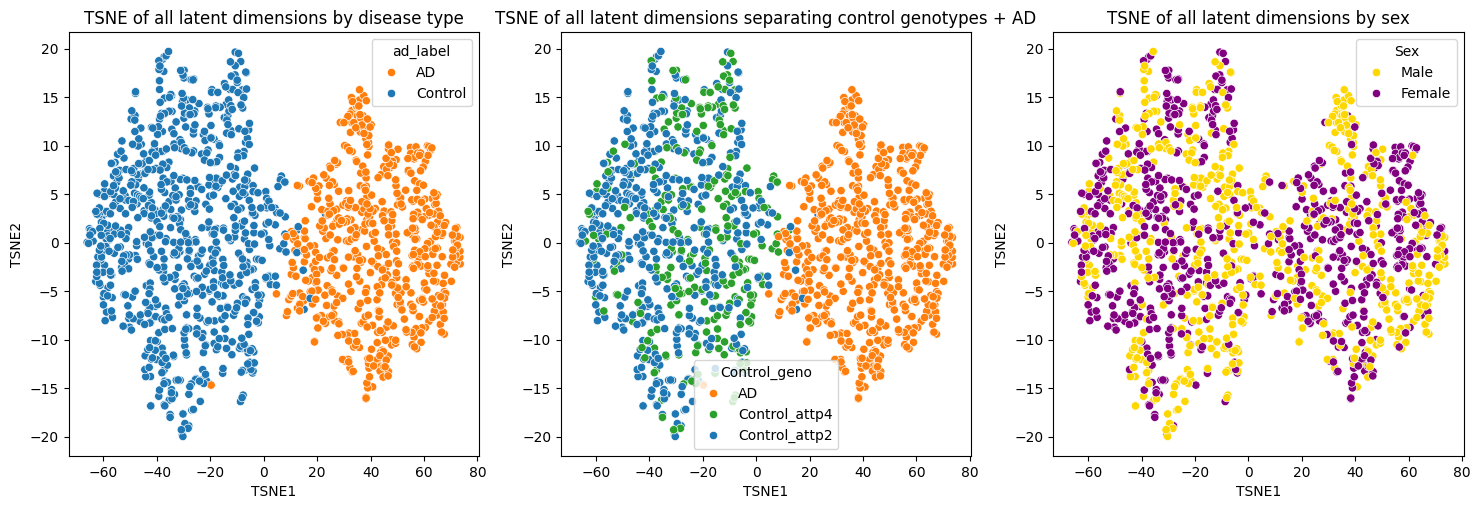

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5.5))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='ad_label', data=tsne_embedding_df, palette=color_mapping_ad, ax=axes[0])
axes[0].set_title('TSNE of all latent dimensions by disease type')
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Control_geno', data=tsne_embedding_df, palette=color_mapping_geno, ax=axes[1])
axes[1].set_title('TSNE of all latent dimensions separating control genotypes + AD')
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Sex', data=tsne_embedding_df, palette=color_mapping_sex, ax=axes[2])
axes[2].set_title('TSNE of all latent dimensions by sex')
plt.savefig(os.path.join(output_path, 'tsne_latent_compression.png'))